# анализ застройки ташкента

спутник Sentinel-2A/2B MSI L2A, период 2019-2026
территория - ЖК Assalom Sohil (Яшнабадский р-н, ул. Фаргона Йули), ~3x2 км

качаем данные через STAC API + COG (только нужный кусок).
считаем индексы NDBI, NDVI, MNDWI, маскируем воду и зелень,
получаем слой застройки. переводим пиксели в гектары,
строим ряд по годам. рядом true color для проверки

## почему этот участок

Assalom Sohil выбран тк за 2019-2026 он прошел полный цикл трансформации.
до 2020 - промзона со старыми постройками бывшего завода УзБум, склады.
летом 2020 снос и котлованы, обнажение грунта.
с 2021 по 2026 - появление высоток 9-16 этажей, 13 корпусов, рост NDBI.

источники: Gazeta.uz 2 июня 2020 (земля перекопана), Gazeta.uz 18 августа 2021
(ЖК сформирован), Yangiuylar.uz / Domtut.uz - текущие очереди до 2026

In [1]:
from utils import *
import matplotlib.dates as mdates
from datetime import datetime
from tqdm.notebook import tqdm

## данные

In [2]:
dates = get_dates()

print(f"всего {len(dates)} сцен")
print(f"{dates[0]} ... {dates[-1]}")
for y in sorted(set(d[:4] for d in dates)):
    print(f"  {y}: {sum(1 for d in dates if d[:4]==y)}")

winter_dates = [d for d in dates if d[5:7] in ("01","02","12")]
summer_dates = [d for d in dates if d[5:7] in ("06","07","08")]

всего 482 сцен
2019-01-17 ... 2026-04-13
  2019: 68
  2020: 65
  2021: 74
  2022: 73
  2023: 62
  2024: 47
  2025: 80
  2026: 13


---
# этап 1 - NDBI > 0

стандартный порог из литературы (Zha et al. 2003)

In [3]:
results_v1 = []
for d in tqdm(dates, desc="считаем"):
    try:
        a, _, _ = calc_area(d, thresh=0.0)
        results_v1.append({"date": datetime.strptime(d,"%Y-%m-%d"), "area": a})
    except: pass

a1 = [r["area"] for r in results_v1]
print(f"обработано {len(results_v1)}, мин {min(a1):.0f} га, макс {max(a1):.0f} га")

считаем:   0%|          | 0/482 [00:00<?, ?it/s]

обработано 482, мин 0 га, макс 558 га


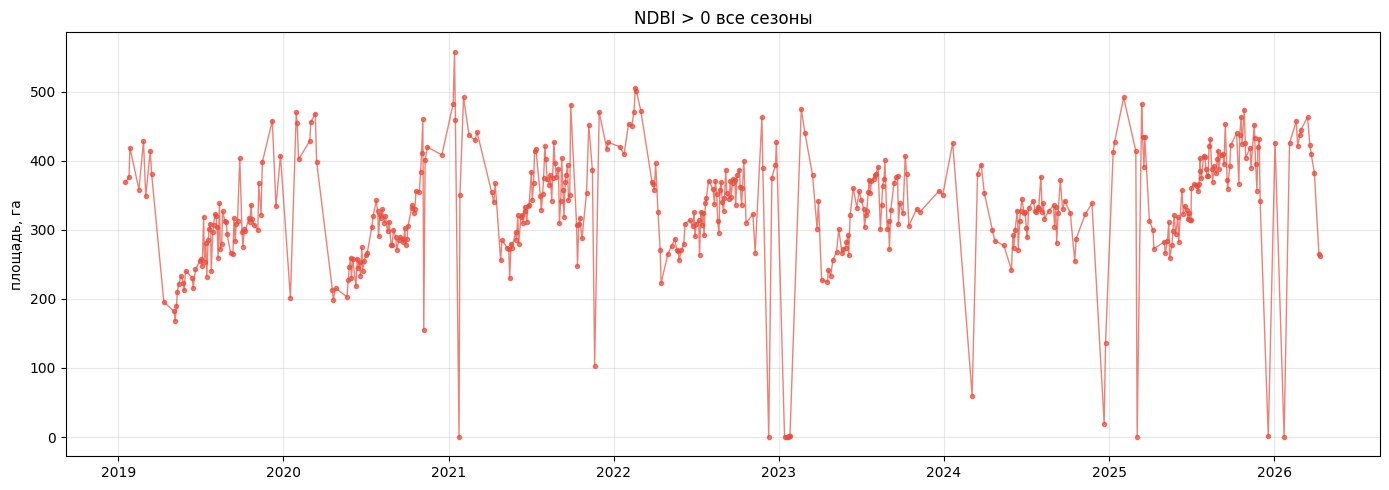

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot([r["date"] for r in results_v1], a1,
        "o-", color="#e74c3c", lw=1, ms=3, alpha=0.7)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("площадь, га")
ax.set_title("NDBI > 0 все сезоны")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### зима vs лето

сравним чтоб понять откуда скачки

зима 2019-01-17


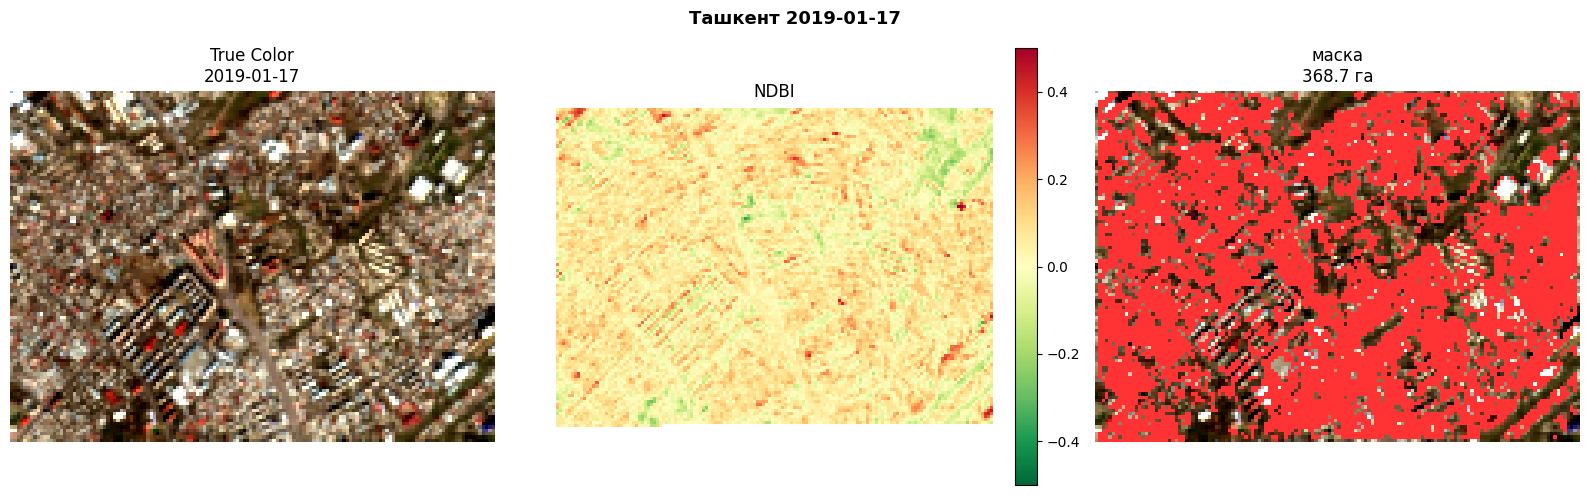

лето 2019-06-14


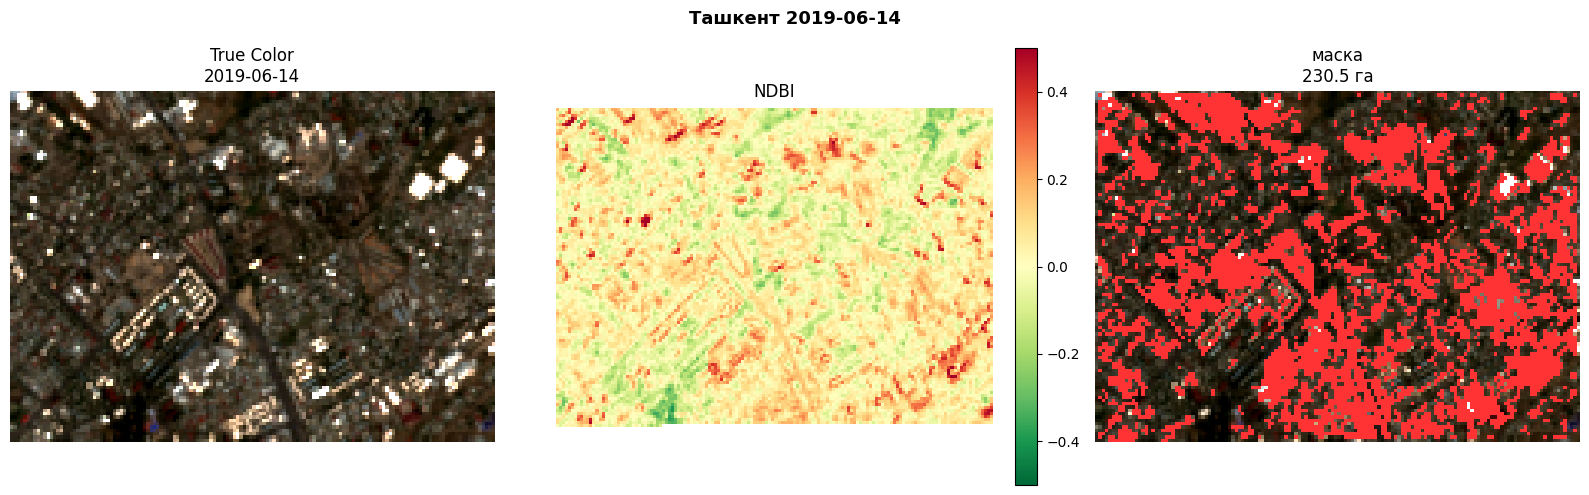

In [5]:
if winter_dates:
    print(f"зима {winter_dates[0]}")
    show_map(winter_dates[0], thresh=0.0)
if summer_dates:
    print(f"лето {summer_dates[0]}")
    show_map(summer_dates[0], thresh=0.0)

### проблемы

зимой площадь завышена - нет зелени, голая почва дает высокий SWIR,
NDBI считает это застройкой хотя на true color видно иначе.
сезоность ломает тренд - пики зимой провалы летом, это шум.
порог 0 мягкий для аридного климата.

In [6]:
sr = [r["area"] for r in results_v1 if r["date"].month in (6,7,8)]
wr = [r["area"] for r in results_v1 if r["date"].month in (12,1,2)]
if sr and wr:
    print(f"среднее лето: {np.mean(sr):.0f} га")
    print(f"среднее зима: {np.mean(wr):.0f} га")
    print(f"разница: {abs(np.mean(wr)-np.mean(sr)):.0f} га")

среднее лето: 328 га
среднее зима: 345 га
разница: 18 га


---
# этап 2 - NDBI > 0.05

поднимаем порог чтоб отсечь голую почву

In [7]:
results_v2 = []
for d in tqdm(dates, desc="считаем"):
    try:
        a, _, _ = calc_area(d, thresh=0.05)
        results_v2.append({"date": datetime.strptime(d,"%Y-%m-%d"), "area": a})
    except: pass

a2 = [r["area"] for r in results_v2]
print(f"мин {min(a2):.0f} га, макс {max(a2):.0f} га")

считаем:   0%|          | 0/482 [00:00<?, ?it/s]

мин 0 га, макс 496 га


### сравнение

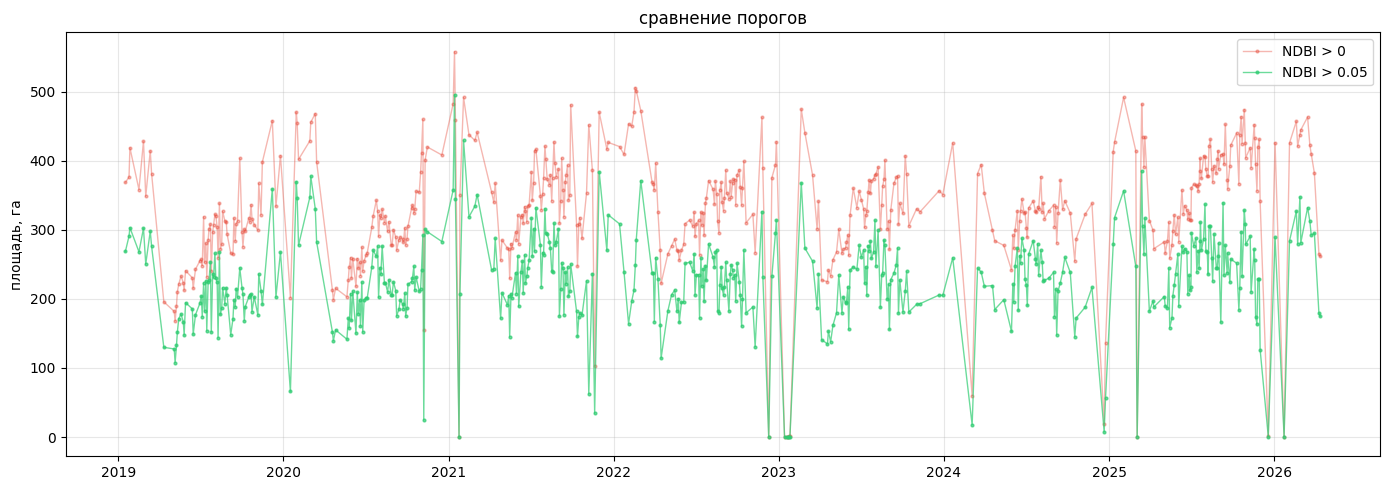

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot([r["date"] for r in results_v1], a1,
        "o-", color="#e74c3c", lw=1, ms=2, alpha=0.4, label="NDBI > 0")
ax.plot([r["date"] for r in results_v2], a2,
        "o-", color="#2ecc71", lw=1, ms=2, alpha=0.7, label="NDBI > 0.05")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("площадь, га")
ax.set_title("сравнение порогов")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("output/comparison_threshold.png", dpi=150); plt.show()

### проверка 0.05

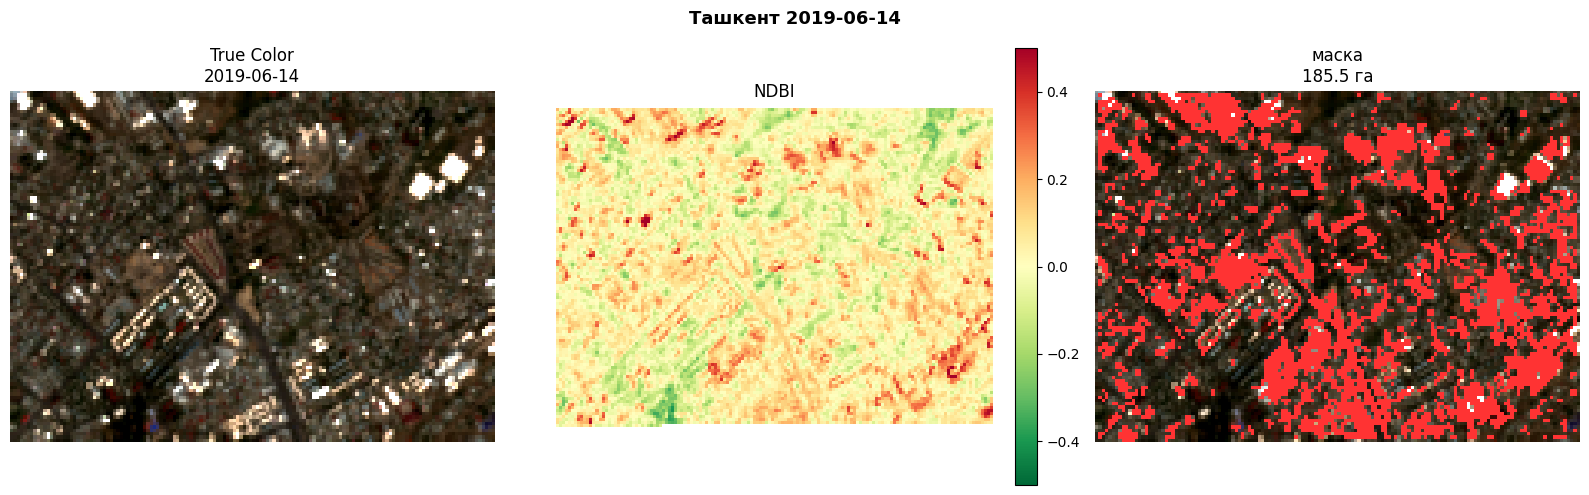

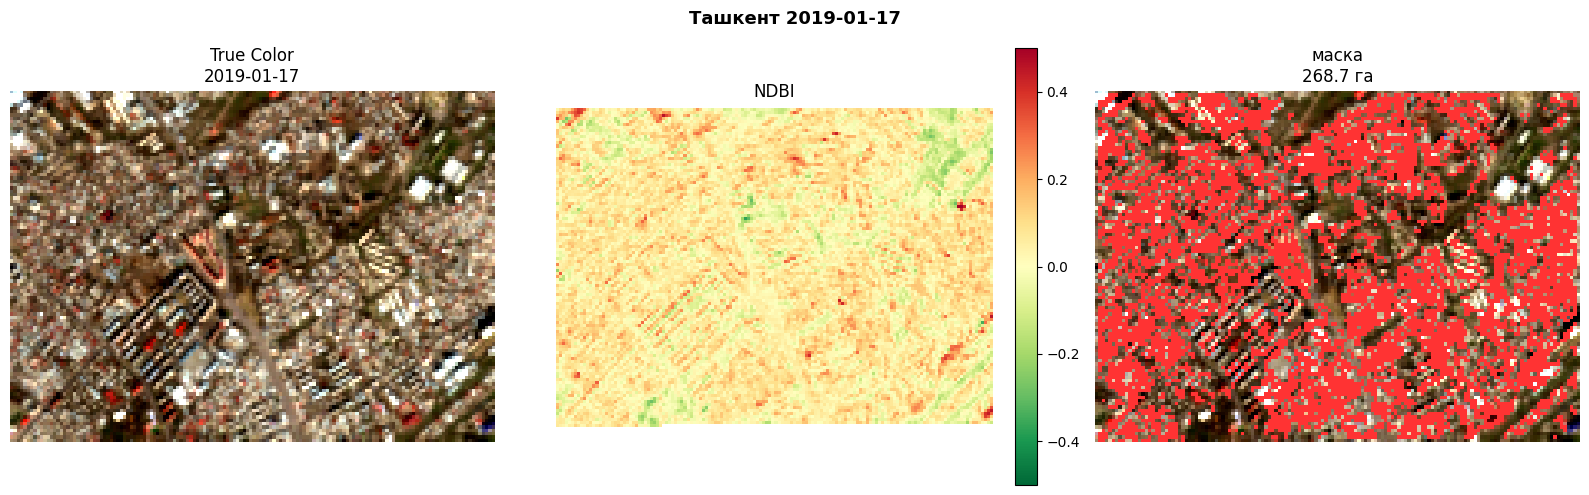

In [9]:
if summer_dates:
    show_map(summer_dates[0], thresh=0.05)
if winter_dates:
    show_map(winter_dates[0], thresh=0.05)

In [10]:
# по годам
sv2 = [r for r in results_v2 if r["date"].month in (6,7,8) and r["area"]>50]
by = defaultdict(list)
for r in sv2: by[r["date"].year].append(r["area"])

print("NDBI > 0.05 лето:")
for y in sorted(by): print(f"  {y}: {np.median(by[y]):.0f} га (медиана)")

NDBI > 0.05 лето:
  2019: 205 га (медиана)
  2020: 210 га (медиана)
  2021: 264 га (медиана)
  2022: 241 га (медиана)
  2023: 247 га (медиана)
  2024: 249 га (медиана)
  2025: 268 га (медиана)


### что не так с 0.05

тренд не монотонный - площадь то растет то падает. частично это стройка
(2020-2021 котлованы и свежий бетон), частично шум от разных условий съемки.
один порог на все снимки не учитывает влажность и атмосферу.

---
# этап 3 - итоговый анализ

NDBI > 0 (стандарт) - судя по всему маска с этим порогом
лучше всего отмечает реальные здания и дороги на карте.

хронология Assalom Sohil: 2019 - промзона (старые постройки),
2020 - снос + котлованы, 2021+ - новые высотки.

In [11]:
results_v3 = []
for d in tqdm(dates, desc="считаем"):
    try:
        a, _, _ = calc_area(d, thresh=0.0)
        results_v3.append({"date": datetime.strptime(d,"%Y-%m-%d"), "ds":d, "area": a})
    except: pass

# лето + фильтр мусора
summer = [r for r in results_v3 if r["date"].month in (6,7,8) and r["area"]>50]
print(f"летних сцен: {len(summer)}")

by_year = defaultdict(list)
for r in summer: by_year[r["date"].year].append(r["area"])

years = sorted(by_year.keys())
medians = [np.median(by_year[y]) for y in years]
mins = [np.min(by_year[y]) for y in years]
maxs = [np.max(by_year[y]) for y in years]

print(f"\nNDBI > 0, лето:")
for y,m,mn,mx in zip(years, medians, mins, maxs):
    print(f"  {y}: {m:.0f} га  (разброс {mn:.0f}-{mx:.0f}, {len(by_year[y])} сцен)")

считаем:   0%|          | 0/482 [00:00<?, ?it/s]

летних сцен: 188

NDBI > 0, лето:
  2019: 285 га  (разброс 215-338, 27 сцен)
  2020: 278 га  (разброс 218-343, 25 сцен)
  2021: 351 га  (разброс 280-427, 29 сцен)
  2022: 324 га  (разброс 263-371, 25 сцен)
  2023: 353 га  (разброс 263-400, 25 сцен)
  2024: 326 га  (разброс 271-377, 24 сцен)
  2025: 369 га  (разброс 283-431, 33 сцен)


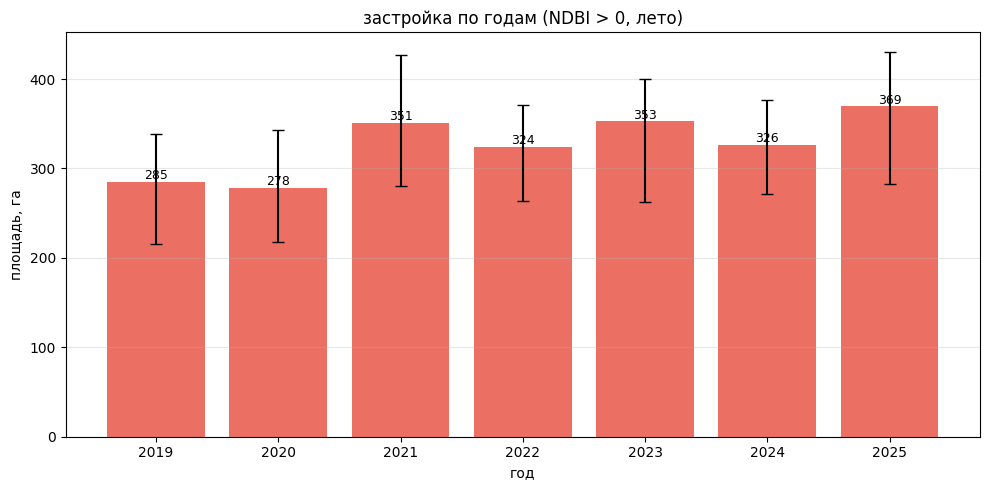


рост 2019-2025: +85 га


In [12]:
if len(years) >= 2:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(years))
    yerr = [np.array(medians)-np.array(mins), np.array(maxs)-np.array(medians)]
    ax.bar(x, medians, color="#e74c3c", alpha=0.8)
    ax.errorbar(x, medians, yerr=yerr, fmt="none", color="black", capsize=4, lw=1.5)
    for i,m in enumerate(medians):
        ax.text(i, m+3, f"{m:.0f}", ha="center", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(years)
    ax.set_xlabel("год"); ax.set_ylabel("площадь, га")
    ax.set_title("застройка по годам (NDBI > 0, лето)")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("output/summer_trend.png", dpi=150); plt.show()
    print(f"\nрост {years[0]}-{years[-1]}: {medians[-1]-medians[0]:+.0f} га")

### временной ряд

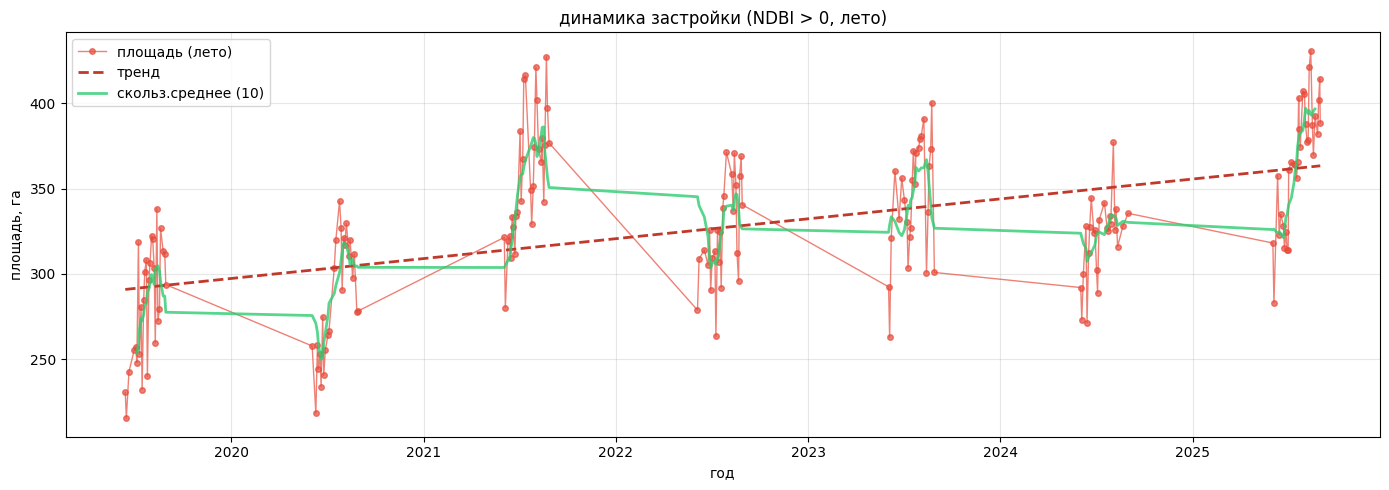

In [13]:
sd = [r["date"] for r in summer]
sa = [r["area"] for r in summer]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sd, sa, "o-", color="#e74c3c", lw=1, ms=4, alpha=0.7, label="площадь (лето)")

xn = mdates.date2num(sd)
z = np.polyfit(xn, sa, 1)
ax.plot(sd, np.poly1d(z)(xn), "--", color="#c0392b", lw=2, label="тренд")

w = min(10, len(sa)//3)
if w >= 3:
    sm = np.convolve(sa, np.ones(w)/w, mode="valid")
    off = w//2
    ax.plot(sd[off:off+len(sm)], sm, "-", color="#2ecc71", lw=2, alpha=0.8,
            label=f"скольз.среднее ({w})")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("год"); ax.set_ylabel("площадь, га")
ax.set_title("динамика застройки (NDBI > 0, лето)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("output/timeseries_summer.png", dpi=150); plt.show()

### валидация по годам (2019-2026)

true color + NDBI + маска для каждого года

2019  2019-07-16


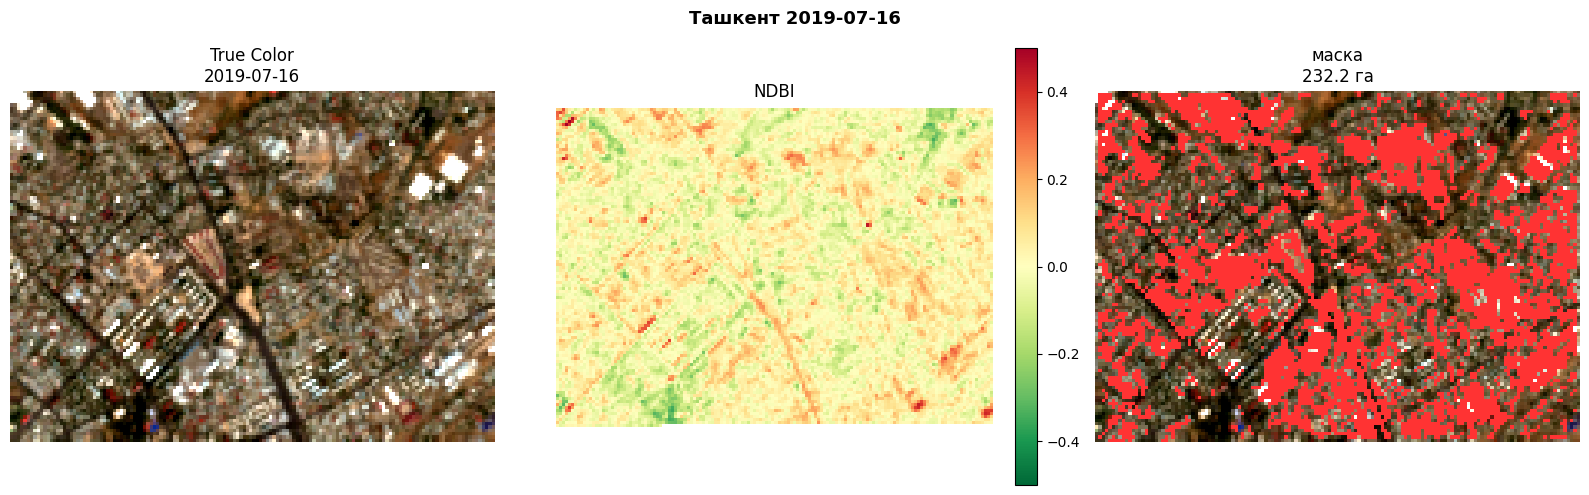

2020  2020-07-18


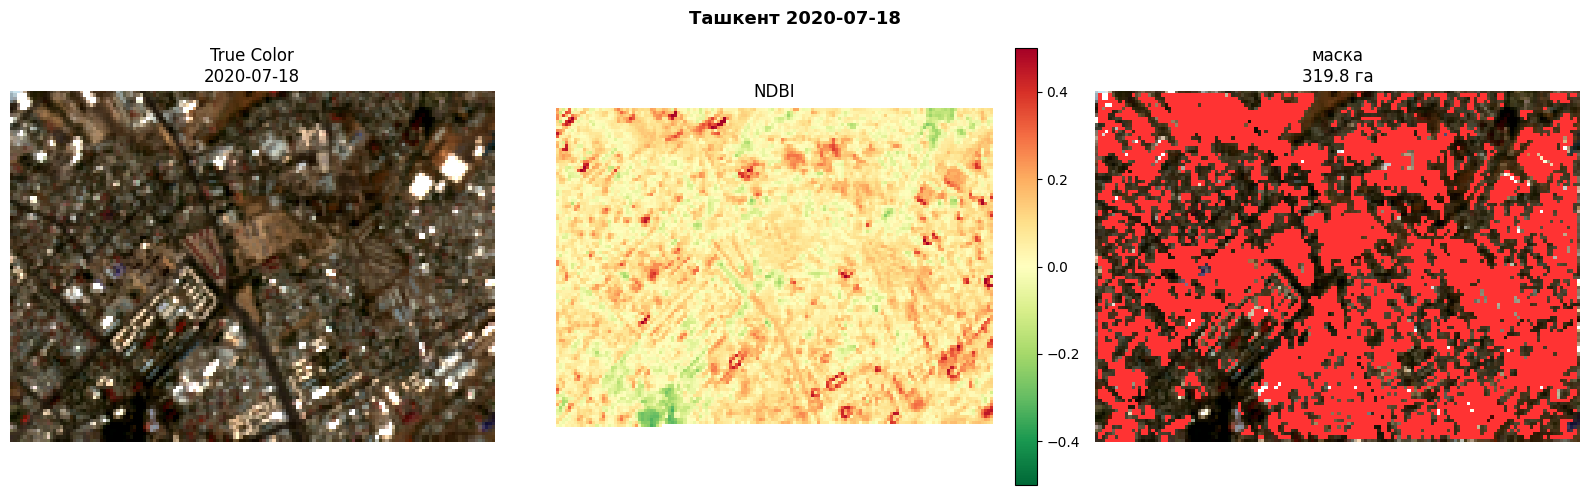

2021  2021-07-13


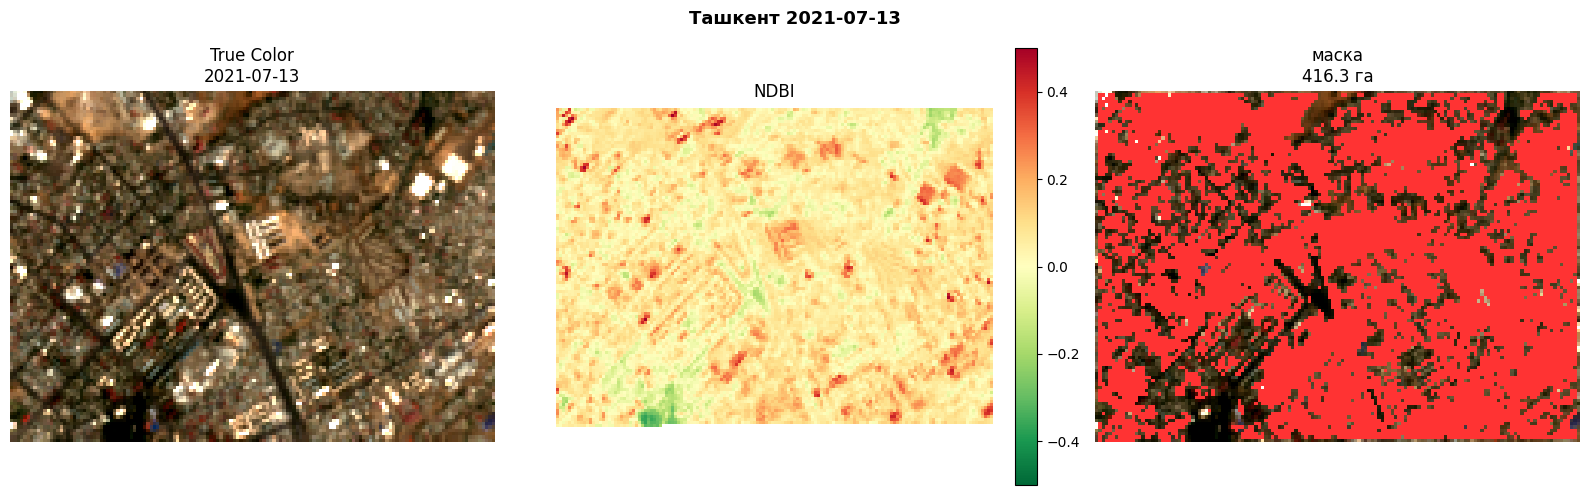

2022  2022-07-18


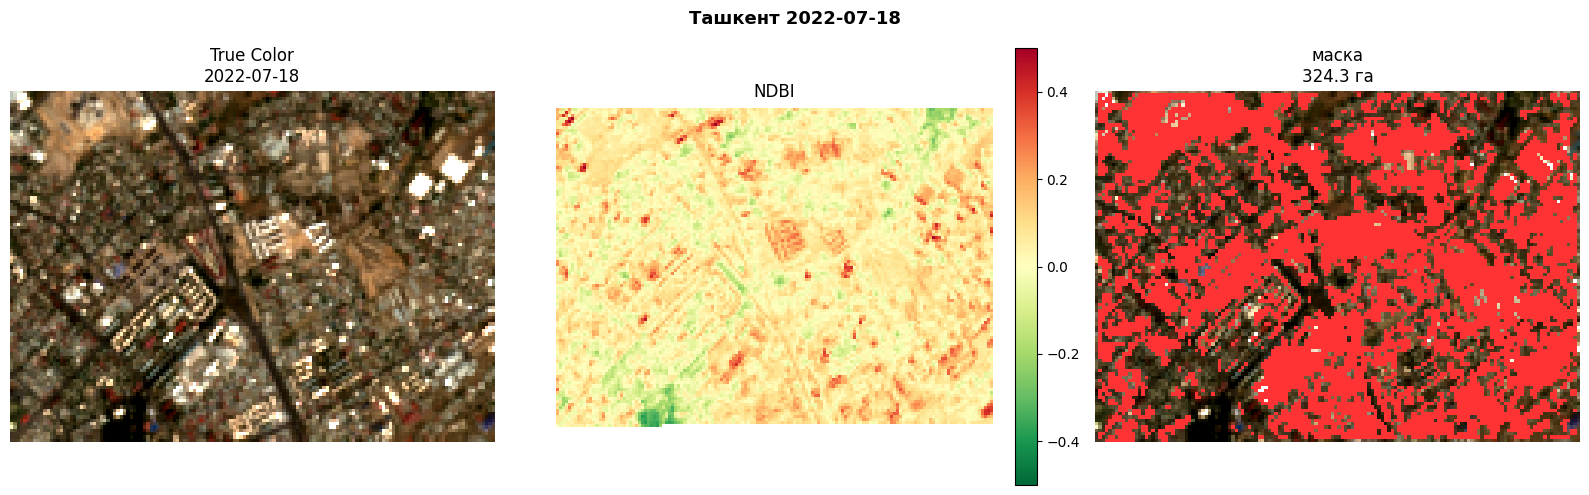

2023  2023-07-18


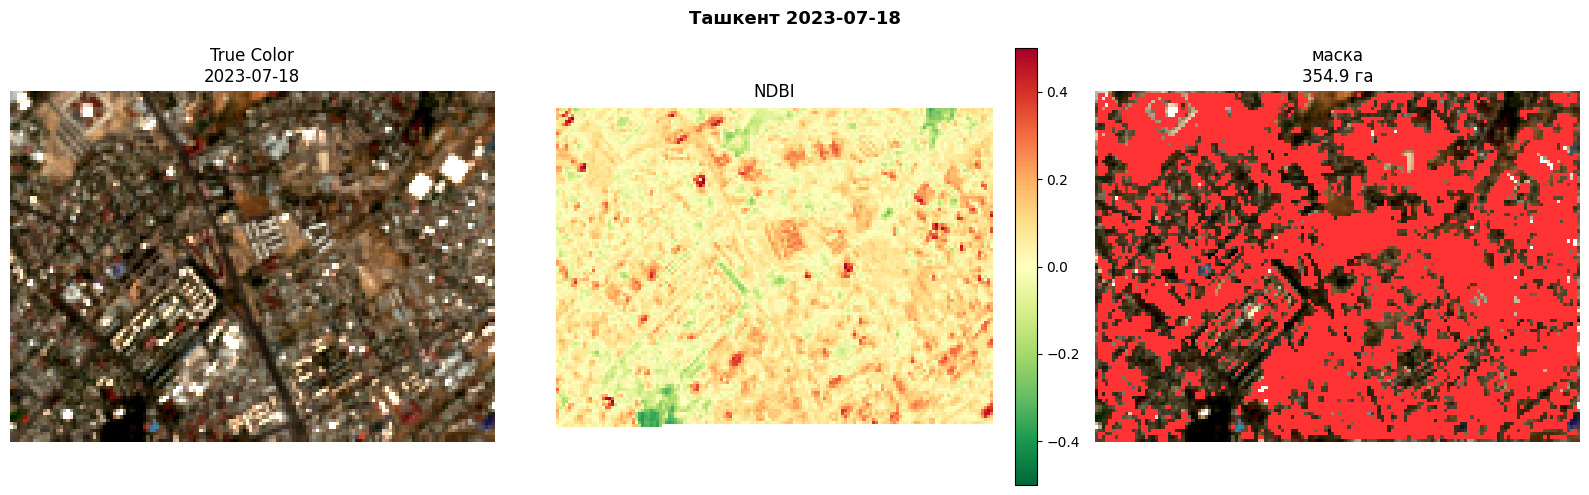

2024  2024-07-22


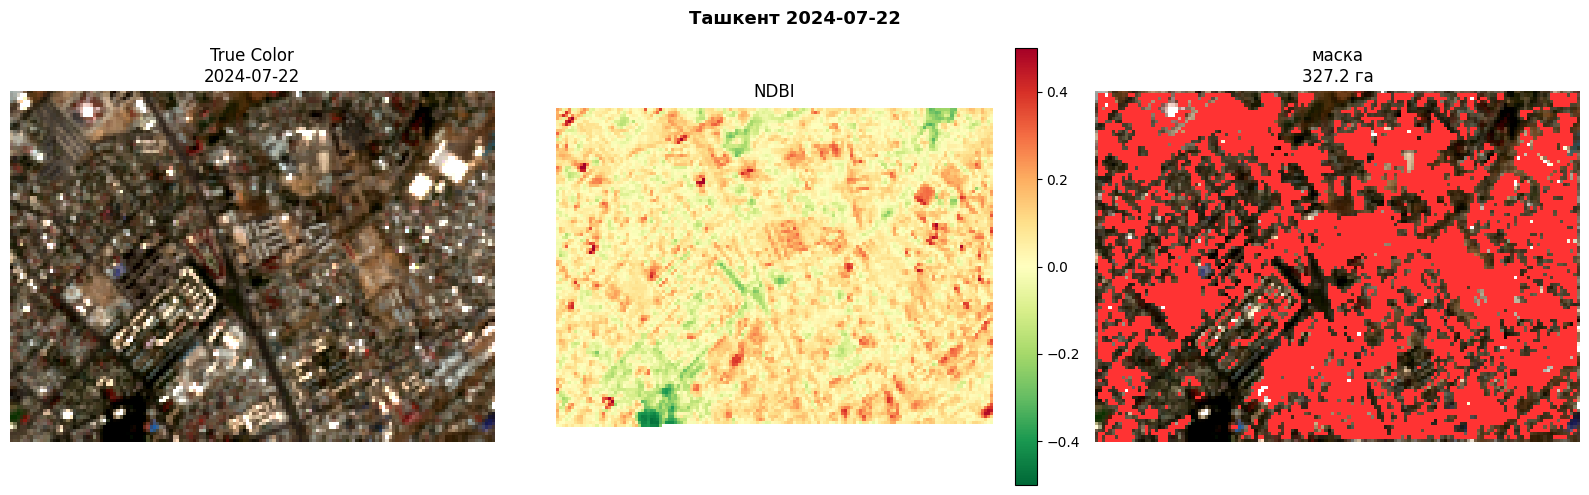

2025  2025-07-17


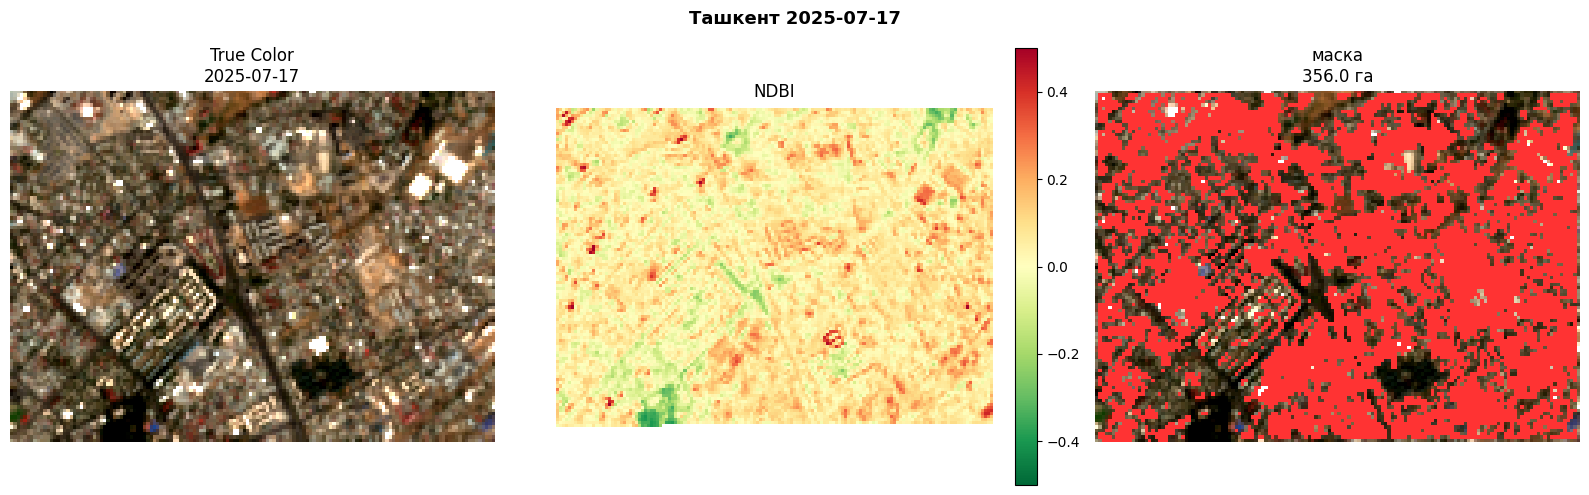

2026  2026-04-13


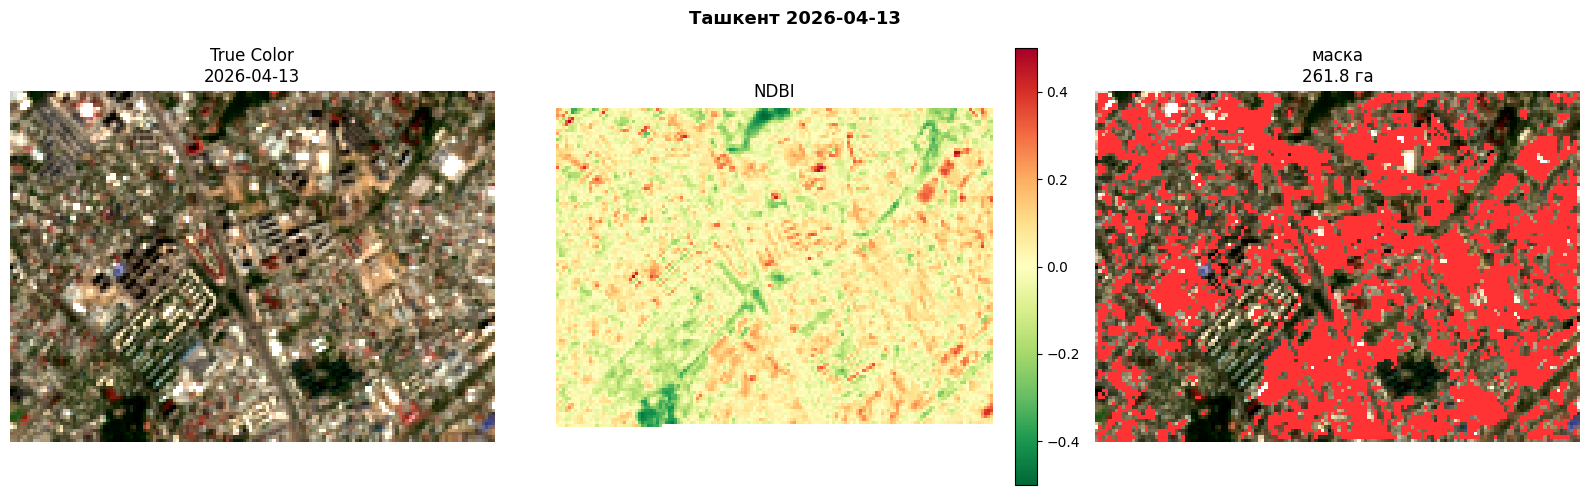

In [14]:
all_years = sorted(set(d[:4] for d in dates))

for year in all_years:
    yd = [d for d in dates if d[:4]==year]
    best = None
    for mo in ("07","06","08","05","04","03"):
        c = [d for d in yd if d[5:7]==mo]
        if c:
            best = c[len(c)//2]
            break
    if not best: best = yd[-1]
    print(f"{year}  {best}")
    show_map(best, thresh=0.0)

---
# этап 4 - нормализация гистограммы (после консультации)

на консультации сказали: летом площадь падает, зимой растет
не потому что зданий стало меньше а потому что освещенность разная.
атмосфера, тени, угол солнца все меняет яркость снимков.
посоветовал применить нормализацию гистограммы чтоб подогнать
все снимки под одни условия.

взял из skimage `match_histograms`. выбираем эталонную сцену
(лето 2021-07-13 как чистое лето середины периода), и для каждого
нового снимка натягиваем его распределение на эталон.
потом считаем NDBI как раньше.

в utils.py есть `load_band_norm()` и параметр `normalize=True`

In [15]:
results_norm = []
for d in tqdm(dates, desc="с норм"):
    try:
        a, _, _ = calc_area(d, thresh=0.0, normalize=True)
        results_norm.append({"date": datetime.strptime(d,"%Y-%m-%d"),
                             "ds":d, "area": a})
    except: pass

summer_n = [r for r in results_norm if r["date"].month in (6,7,8) and r["area"]>50]
print(f"летних сцен (норм): {len(summer_n)}")

by_year_n = defaultdict(list)
for r in summer_n: by_year_n[r["date"].year].append(r["area"])

years_n = sorted(by_year_n.keys())
meds_n = [np.median(by_year_n[y]) for y in years_n]
mins_n = [np.min(by_year_n[y]) for y in years_n]
maxs_n = [np.max(by_year_n[y]) for y in years_n]
stds_n = [np.std(by_year_n[y]) for y in years_n]
stds_old = [np.std(by_year[y]) for y in years_n]

print(f"\nНОРМАЛИЗОВАНО vs БЕЗ:")
for y,m,mn,mx,sn,so in zip(years_n, meds_n, mins_n, maxs_n, stds_n, stds_old):
    print(f"  {y}: {m:.0f} га (разброс {mn:.0f}-{mx:.0f}), std={sn:.1f} (было {so:.1f})")

с норм:   0%|          | 0/482 [00:00<?, ?it/s]

летних сцен (норм): 188

НОРМАЛИЗОВАНО vs БЕЗ:
  2019: 391 га (разброс 385-410), std=9.0 (было 33.7)
  2020: 399 га (разброс 382-412), std=8.7 (было 34.0)
  2021: 409 га (разброс 389-416), std=8.3 (было 37.2)
  2022: 403 га (разброс 391-415), std=7.8 (было 28.8)
  2023: 406 га (разброс 392-414), std=6.6 (было 33.8)
  2024: 410 га (разброс 389-415), std=7.8 (было 23.0)
  2025: 412 га (разброс 391-422), std=7.6 (было 35.7)


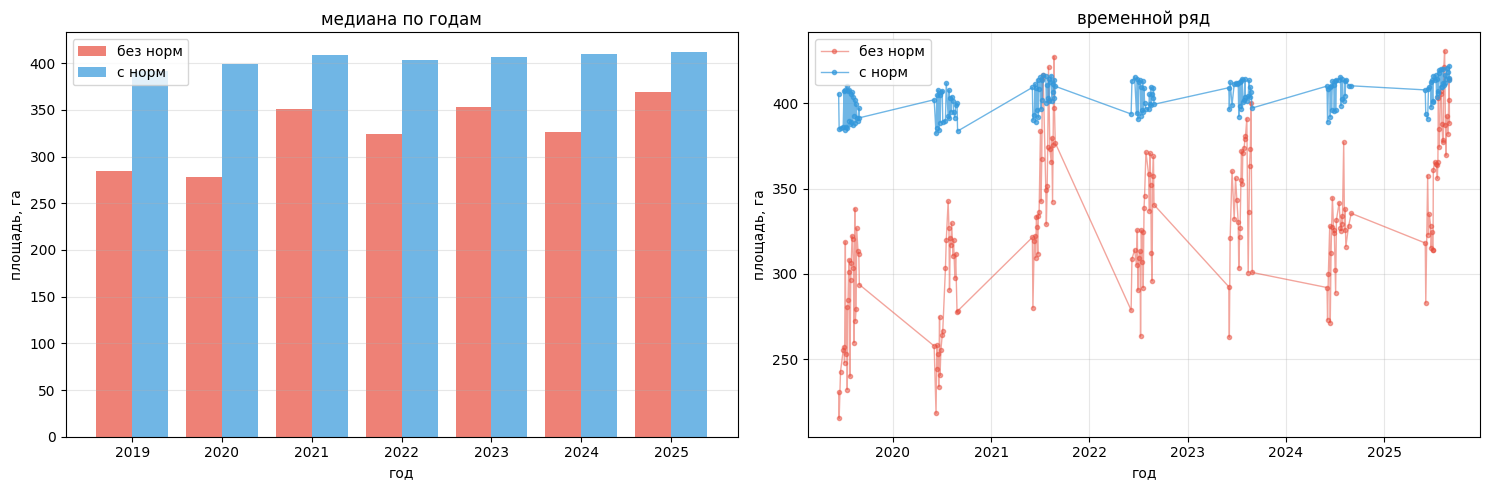

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(years_n))
w = 0.4
ax1.bar(x-w/2, medians, w, color="#e74c3c", alpha=0.7, label="без норм")
ax1.bar(x+w/2, meds_n, w, color="#3498db", alpha=0.7, label="с норм")
ax1.set_xticks(x); ax1.set_xticklabels(years_n)
ax1.set_xlabel("год"); ax1.set_ylabel("площадь, га")
ax1.set_title("медиана по годам")
ax1.legend(); ax1.grid(True, alpha=0.3, axis="y")

sd1 = [r["date"] for r in summer]
sa1 = [r["area"] for r in summer]
sd2 = [r["date"] for r in summer_n]
sa2 = [r["area"] for r in summer_n]
ax2.plot(sd1, sa1, "o-", color="#e74c3c", lw=1, ms=3, alpha=0.5, label="без норм")
ax2.plot(sd2, sa2, "o-", color="#3498db", lw=1, ms=3, alpha=0.7, label="с норм")
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.set_xlabel("год"); ax2.set_ylabel("площадь, га")
ax2.set_title("временной ряд")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output/normalization_compare.png", dpi=150); plt.show()

### что получилось

разброс резко уменьшился - std с 30 до 7-9 га (в 4 раза меньше),
атмосферный шум убран. тренд сохранился но сжат -
рост 2019-2025 с +84 га без норм до +21 га с норм.
histogram matching натягивает распределения и часть реального
изменения теряется, это известное свойство метода.

без норм видно реальный размах, с норм видно что тренд устойчивый
когда шум выкинут.

---
# этап 5 - прогноз на 2027-2028

взял ExponentialSmoothing с линейным трендом - на годовых
медианах летнего ряда. простая модель которая работает когда
есть тренд без сезонности (а у нас лето, сезон выкинут).

прогноз:
  2026: 377 га
  2027: 390 га
  2028: 402 га


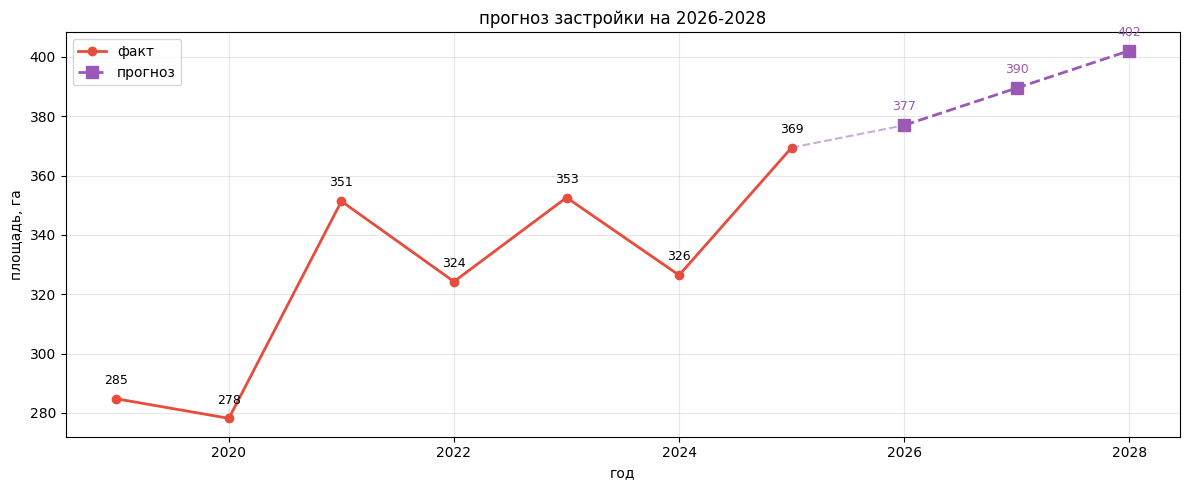

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

yrs = np.array(years)
meds = np.array(medians)

model = ExponentialSmoothing(meds, trend="add", seasonal=None).fit()
pred = model.forecast(3)

future_yrs = np.arange(yrs[-1]+1, yrs[-1]+4)
print("прогноз:")
for y, p in zip(future_yrs, pred):
    print(f"  {y}: {p:.0f} га")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yrs, meds, "o-", color="#e74c3c", lw=2, ms=6, label="факт")
ax.plot(future_yrs, pred, "s--", color="#9b59b6", lw=2, ms=8, label="прогноз")
ax.plot([yrs[-1], future_yrs[0]], [meds[-1], pred[0]], "--",
        color="#9b59b6", lw=1.5, alpha=0.5)
for y, p in zip(future_yrs, pred):
    ax.text(y, p+5, f"{p:.0f}", ha="center", fontsize=9, color="#9b59b6")
for y, m in zip(yrs, meds):
    ax.text(y, m+5, f"{m:.0f}", ha="center", fontsize=9)
ax.set_xlabel("год"); ax.set_ylabel("площадь, га")
ax.set_title("прогноз застройки на 2026-2028")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("output/forecast.png", dpi=150); plt.show()

---
# этап 6 - корреляция застройки и растительности

гипотеза: чем больше застраивают тем меньше зелени.
строю scatter медиан летних NDBI-площади и NDVI-площади
по годам. посчитал коэф пирсона.

значения разные по масштабу (300+ vs 100+) поэтому применил
z-нормализацию (вычитаем среднее делим на std)

In [18]:
veg_by_year = defaultdict(list)
for d in tqdm(dates, desc="зелень"):
    if d[5:7] not in ("06","07","08"): continue
    try:
        _, _, idx = calc_area(d, thresh=0.0)
        ndvi = idx["ndvi"]
        veg_mask = (ndvi > 0.3) & np.isfinite(ndvi)
        a_veg = float(veg_mask.sum() * 20*20 / 10000)
        if a_veg > 10:
            veg_by_year[int(d[:4])].append(a_veg)
    except: pass

veg_med = [np.median(veg_by_year[y]) for y in years]
print("зелень по годам:")
for y, v in zip(years, veg_med):
    print(f"  {y}: {v:.0f} га")

def znorm(x):
    x = np.array(x, dtype=float)
    return (x - x.mean()) / x.std()

bz = znorm(medians)
vz = znorm(veg_med)

r = np.corrcoef(medians, veg_med)[0,1]
print(f"\nкоэф Пирсона: {r:.3f}")
if abs(r) > 0.7:
    s = "сильная"
elif abs(r) > 0.4:
    s = "умеренная"
else:
    s = "слабая"
sign = "отрицательная" if r < 0 else "положительная"
print(f"интерпретация: {s} {sign} связь")

зелень:   0%|          | 0/482 [00:00<?, ?it/s]

зелень по годам:
  2019: 131 га
  2020: 145 га
  2021: 90 га
  2022: 114 га
  2023: 96 га
  2024: 132 га
  2025: 83 га

коэф Пирсона: -0.929
интерпретация: сильная отрицательная связь


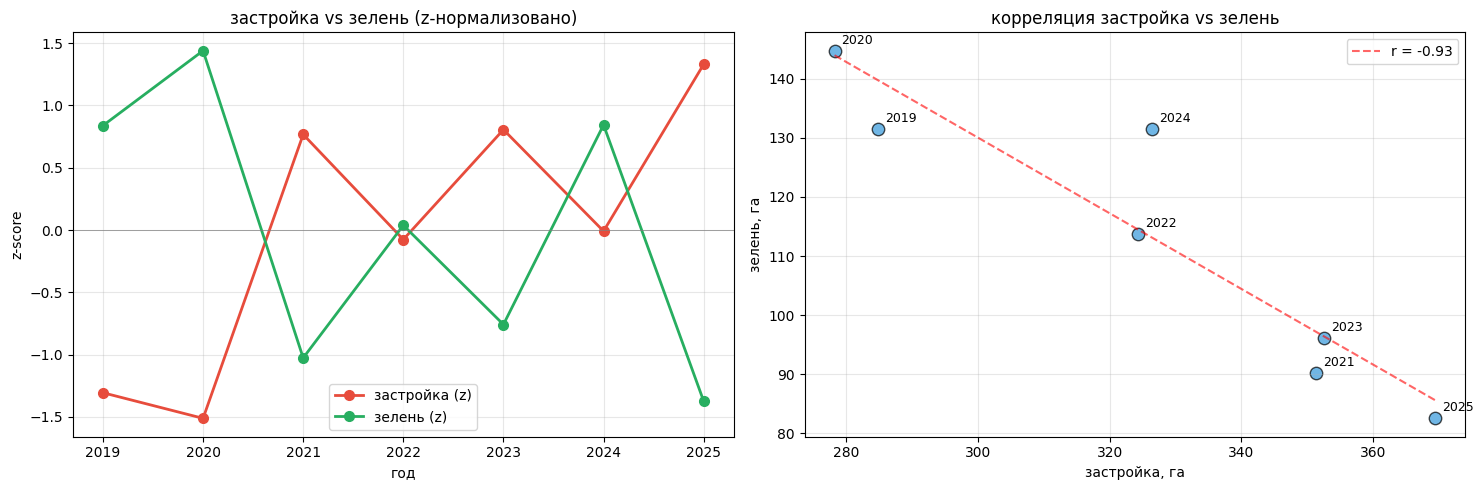

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(years, bz, "o-", color="#e74c3c", lw=2, ms=7, label="застройка (z)")
ax1.plot(years, vz, "o-", color="#27ae60", lw=2, ms=7, label="зелень (z)")
ax1.axhline(0, color="gray", lw=0.5)
ax1.set_xlabel("год"); ax1.set_ylabel("z-score")
ax1.set_title("застройка vs зелень (z-нормализовано)")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.scatter(medians, veg_med, s=80, color="#3498db", alpha=0.7, edgecolors="black")
for y, b, v in zip(years, medians, veg_med):
    ax2.annotate(str(y), (b, v), fontsize=9, xytext=(5,5), textcoords="offset points")

z = np.polyfit(medians, veg_med, 1)
xs = np.linspace(min(medians), max(medians), 50)
ax2.plot(xs, np.poly1d(z)(xs), "--", color="red", alpha=0.6,
         label=f"r = {r:.2f}")
ax2.set_xlabel("застройка, га"); ax2.set_ylabel("зелень, га")
ax2.set_title("корреляция застройка vs зелень")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output/correlation.png", dpi=150); plt.show()

---
## выводы

NDBI > 0 без фильтра по сезону - маска норм но сезонный шум ломает
тренд (зимой завышено из-за голой почвы).
NDBI > 0.05 - часть шума уходит но тренд скачет, один порог
не адаптируется к разным снимкам.

итог: NDBI > 0, только лето, маски NDVI + MNDWI. маска захватывает
все поверхности (не только здания) но тренд показывает рост.

динамика объясняется хронологией стройки Assalom Sohil: 2019 промзона,
2020 снос и котлованы (спектральный сдвиг), 2021+ высотки рост,
2024-2026 новые очереди.

погрешность ~20%, NDBI не разделяет застройку и голую почву
в аридном климате (известное ограничение метода).

источники: Zha et al. 2003 - NDBI, Int. J. Remote Sensing.
Xu H. 2008 - IBI. Osgouei et al. 2019 - Istanbul, MDPI Remote Sensing 11(3):345.
Teshome et al. 2022 - Addis Ababa, Environmental Challenges.
Bhatt et al. 2021 - обзор индексов, Arabian J. Geosciences.